# **Exercise 1**: Run your first SFINCS model for Charleston

In this exercise we will run an existing SFINCS model for the area around Charleston. Afterwards you will analyse the results in the next notebook.
After doing this exercise you will know how to run a SFINCS model. 

We will follow the following steps to create the model:

- Step 0: Import dependencies
- Step 1: Load existing model
- Step 2: Visualise model
- Step 3: Download executable
- Step 4: Run SFINCS model

## **Step 0:** Import dependencies

Before anything else we need to import the required packages

In [1]:
from pathlib import Path

import hydromt
import hydromt_sfincs

from hydromt_sfincs import SfincsModel
from sfincs_utils import run_sfincs

Check version of hydromt_sfincs

In [2]:
# NOTE you need at least version >=0.9.2
print("HydroMT core version", hydromt.__version__)

# NOTE you need at least version >=1.0.2
print("HydroMT-SFINCS version", hydromt_sfincs.__version__)

HydroMT core version 0.10.1
HydroMT-SFINCS version 1.2.2


## **Step 1:** Load existing model
The first step is to load the existing model results by providing:
 - `root_folder`: Folder where the model was saved. Path is relative to current working directory. We are loading in the model "Charleston_subgrid_example_basicforcing"

In [3]:
root_folder  = Path('../Charleston_subgrid_example_basicforcing')

sf = SfincsModel(root=root_folder, mode='r')
sf.read()

## **Step 2:** Visualise model
Now we use the HydroMT function 'plot_basemap' to get a quick idea what the model looks like.
We plot the elevation of the model 'dep', including more information on boundaries and observations points (more on that later during the course).

More information on the function plot_basemap can be found in the online documention of HydroMT-SFINCS, in the API reference:  https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.SfincsModel.plot_basemap.html#hydromt_sfincs.SfincsModel.plot_basemap

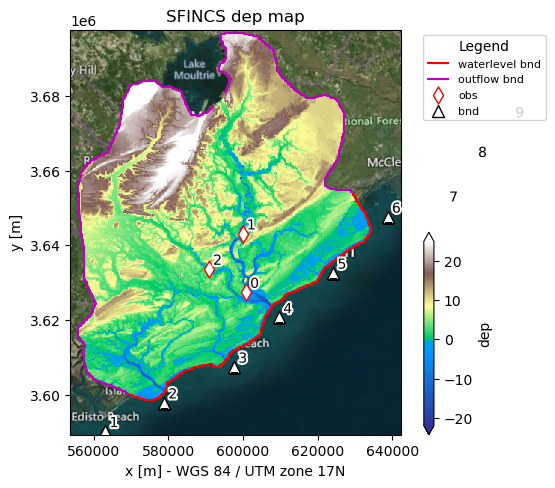

In [4]:
_ = sf.plot_basemap(
    variable='dep', # plot the bed levels
    bmap='sat', # use satellite background
) 

## **Step 3:** Download executable

You can download the latest official SFINCS release from here:  https://download.deltares.nl/sfincs

After making a 'MyDeltares' account (if you don't have one already), you can download the executable for free.

Note that the version of the executable can be different from the version in the screenshot below.

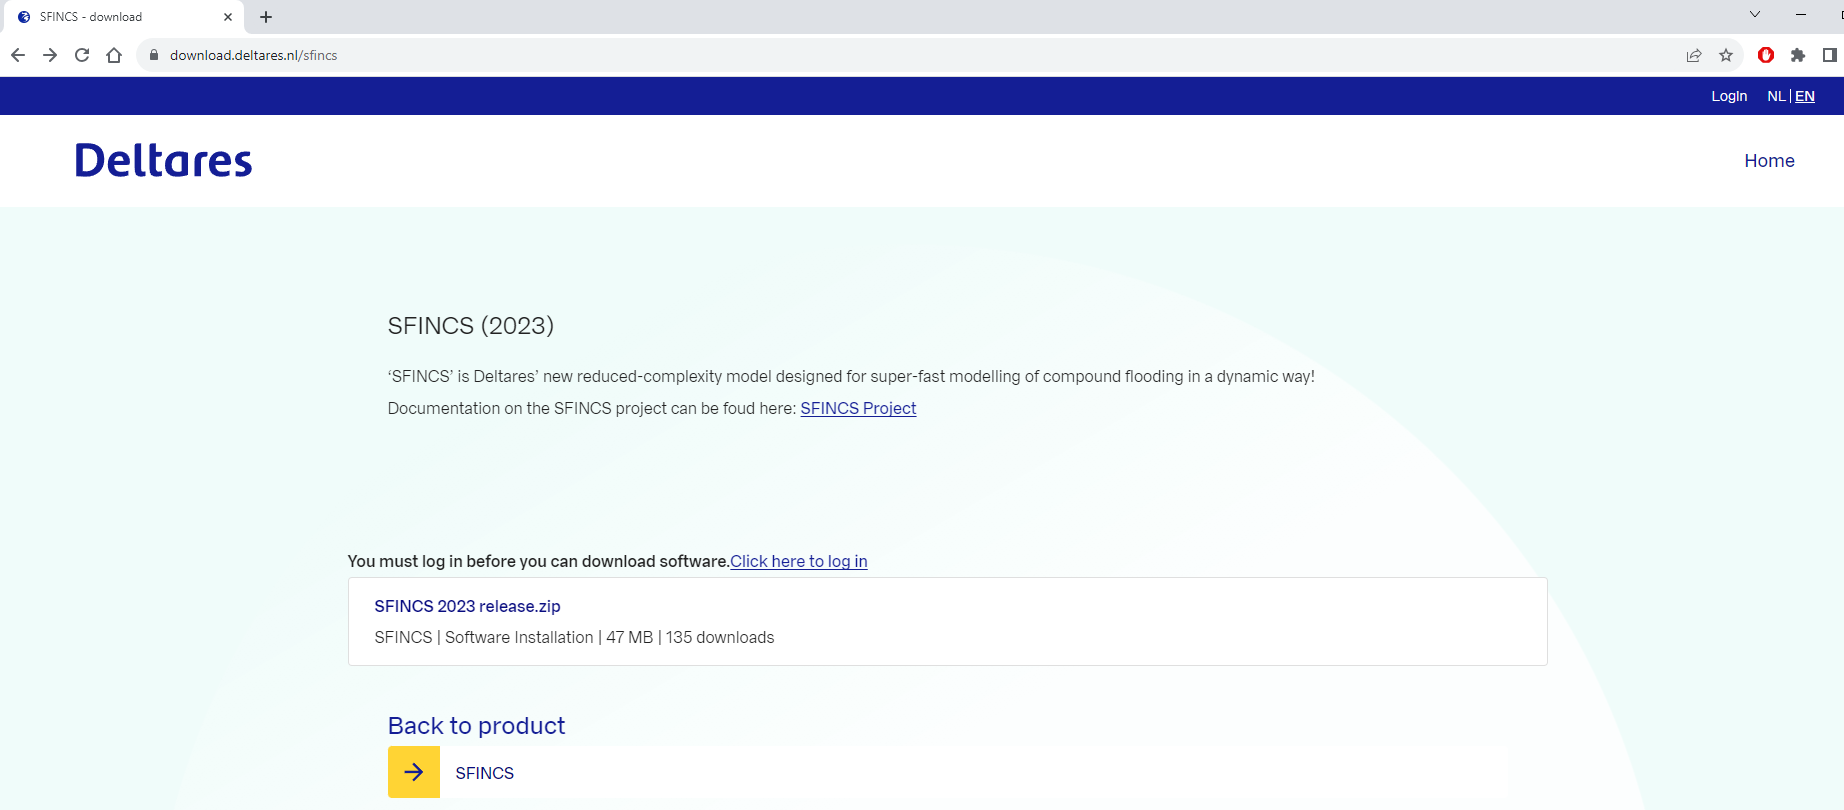

After logging in, you should see this:

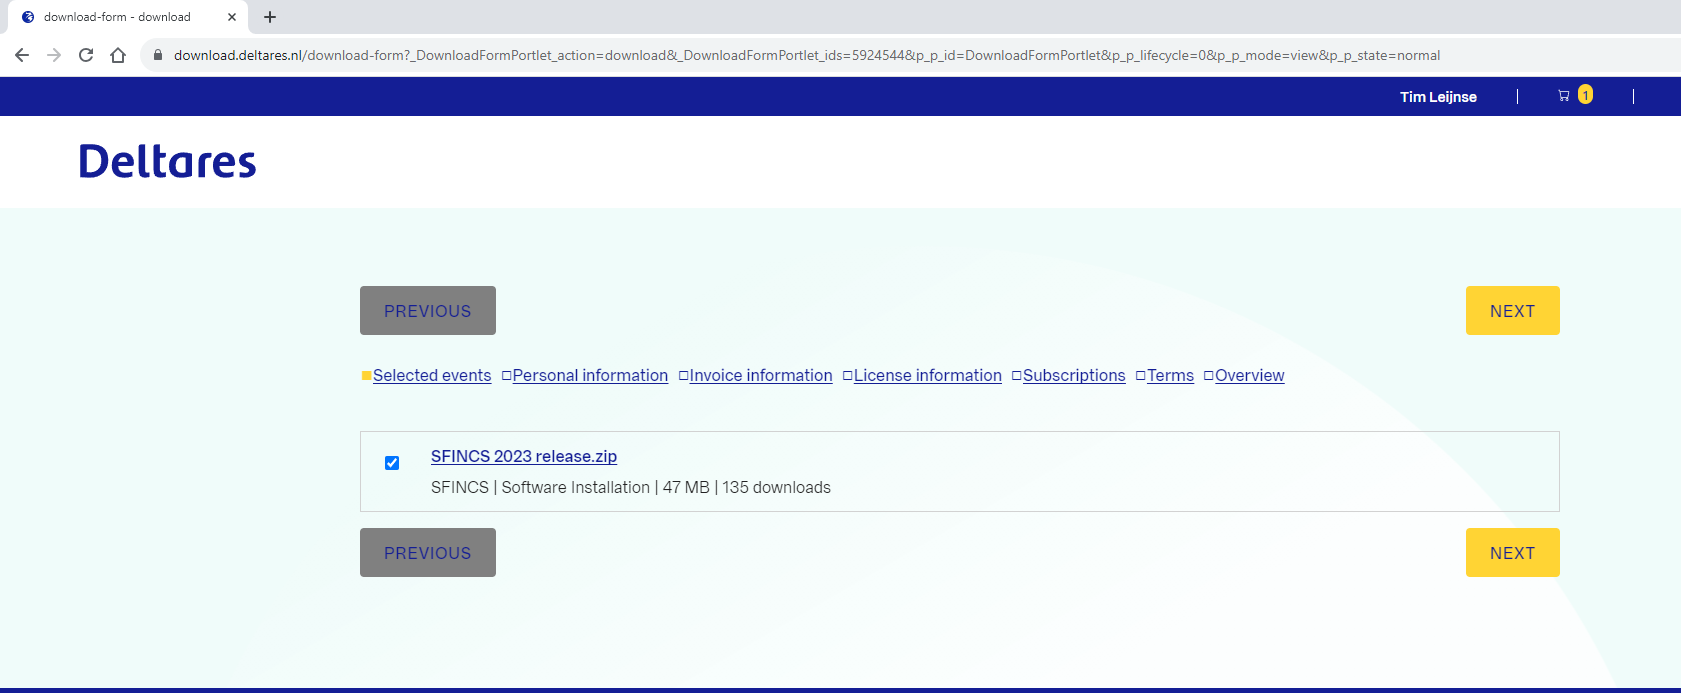

After clicking next and filling in some information and going through the steps you get here:

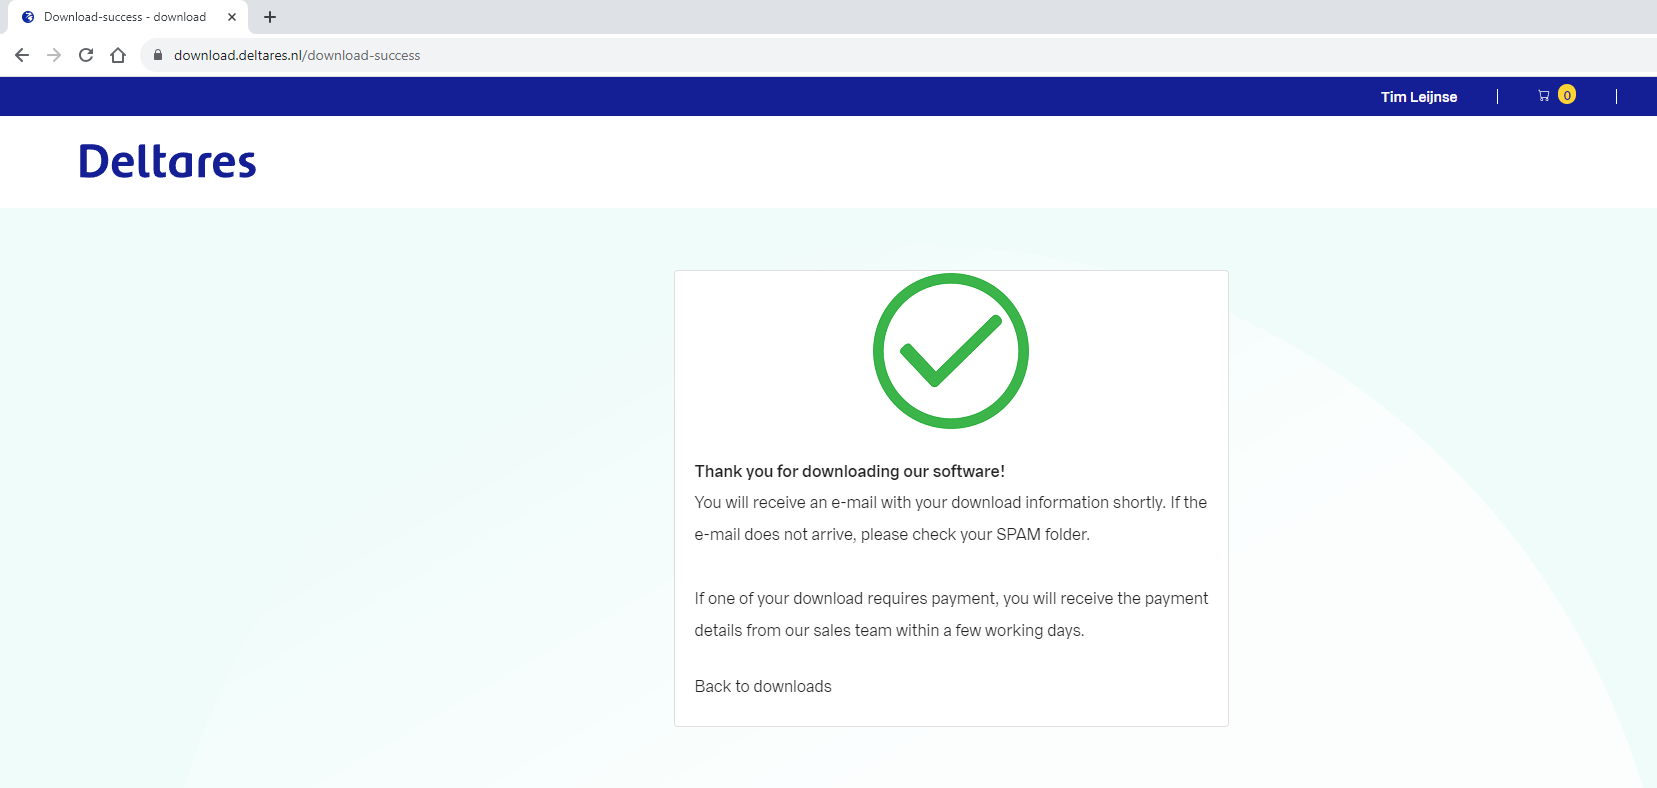

You will get an email like this:

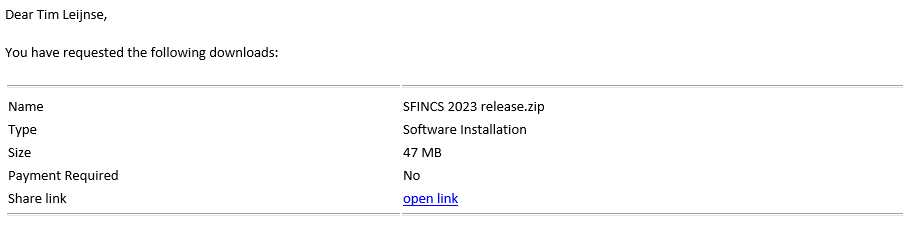

Click on the link to go to the download portal:

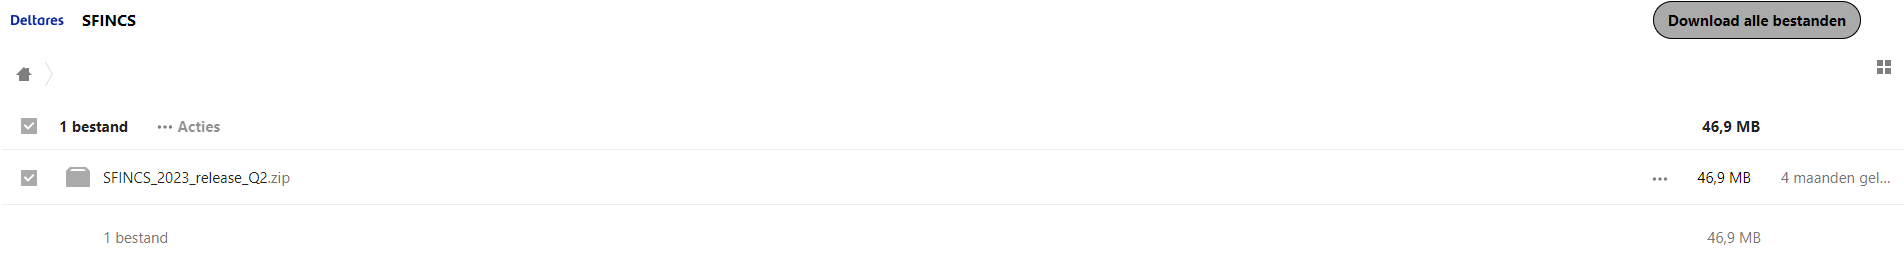

Click on 'Download all' / 'Download alle bestanden', and look in your pcs download folder:

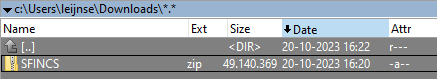

Do a right mouse click and 'unzip' / 'extract all' (twice if needed), you should be left with something like this:

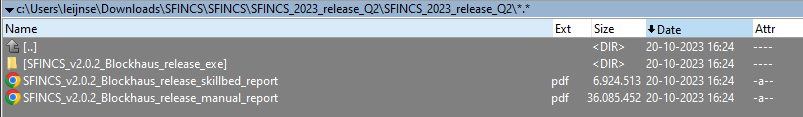

This contains the pdf manual and skillbed reports of the latest release, as well as the folder '<version>_release_exe' with the executable of SFINCS, called 'sfincs.exe'. You can put this folder anywhere you find easy, for example in the 
"../../00_software" folder of this course.

Getting there!

## **Step 4:** Run SFINCS model

Now we can (finally) run your SFINCS model!

You should see the log of the model running in the notebook, and after a while the model should finish.

If not on Windows you can use Docker Desktop (Windows, MacOS, or Linux) or Singularity (Linux) to run the model.
Note that you need to have the Docker or Singularity pre-installed on your computer. 
At first use it will take some time to download the docker image, but after that it should run smoothly.

In [5]:
?run_sfincs

Signature:
run_sfincs(
    model_root: Union[pathlib.Path, str],
    sfincs_exe: Union[str, pathlib.Path, NoneType] = None,
    vm: Optional[str] = None,
    docker_tag: str = 'latest',
    verbose: bool = True,
) -> None
Docstring:
Run the SFINCS model.

Either sfincs_exe or vm must be specified. 
If both are specified, sfincs_exe is used.

Parameters
----------
model_root : Path, str
    The root directory of the model.
sfincs_exe : Path, str, optional
    The path to the SFINCS executable, by default None.
vm : str, optional
    The virtual machine to use, either 'docker' or 'singularity', by default None.
docker_tag : str, optional
    The tag of the docker image to use, by default 'latest'. 
    See https://hub.docker.com/r/deltares/sfincs-cpu/tags for available tags.
    Only used if vm is not None.
verbose : bool, optional
    If True, print the output of the SFINCS model to the console, by default True.
File:      c:\phd\sfincs\sfincs_charleston\02_hands-on\notebook_answers\sfi

In [6]:
# NOTE you need to download the SFINCS executable first (see above) and update the path below
sfincs_exe = Path("../../00_software/SFINCS_2025_02_release", "SFINCS_v2.3.0_mt_Faber_release_exe", "sfincs.exe")

run_sfincs(
    root_folder, # path to the SFINCS model root folder
    sfincs_exe=sfincs_exe, # path to the sfincs executable if you want to run SFINCS on windows
    vm=None, # you can use 'docker' if you want to run SFINCS on linux or mac, but you need to install docker desktop first
)


>> c:\PhD\SFINCS\SFINCS_Charleston\00_software\SFINCS_2025_02_release\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@....

## **Questions**

- Did your simulation finish successfully?
- How long did it take to run the model?

## **Done**

Congrats, you ran your first SFINCS model!

Now you can continue with analysing the output in the notebook: *SFINCS_course_02_analyse_your_first_model.ipynb*

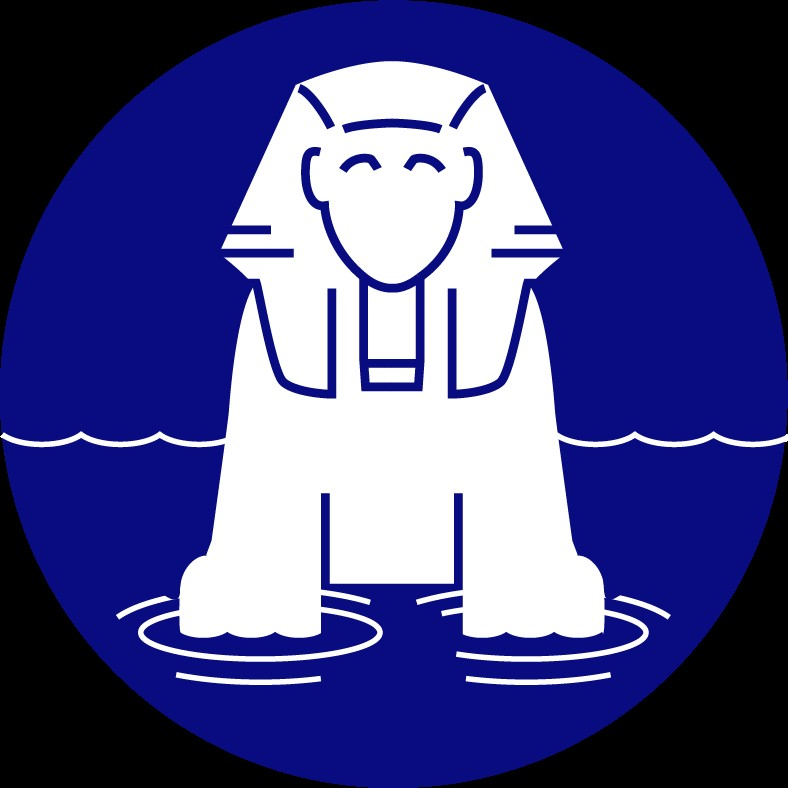